# Analisis Regresi Linier Berganda untuk Prediksi 'Nilai Ekspor'


### Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from google.colab import drive
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### Pengaturan Opsi Tampilan Pandas

In [ ]:
pd.set_option('display.max_columns', None) #melihat semua kolom

### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/My Drive/SKRIPSI/')

Mounted at /content/drive


### Long Format

In [ ]:
bulan = ['January','February','March','April','May','June','July','August','September','October','November','December']
map_bulan = {m:i+1 for i,m in enumerate(bulan)}

def to_long(path, tahun, value_name):
    df = pd.read_csv(path, sep=';')
    df.columns = df.columns.str.strip()

    prov_col = next(c for c in df.columns if 'prov' in c.lower())

    # ubah semua kolom bulan jadi numeric
    for b in bulan:
        df[b] = (df[b].astype(str)
                      .str.replace('.', '', regex=False)
                      .str.replace(',', '.', regex=False)
                      .astype(float))

    out = df.melt(prov_col, bulan, var_name='Bulan', value_name=value_name)
    out = out.rename(columns={prov_col:'Provinsi'})
    out['Tahun'] = tahun
    out['Bulan'] = out['Bulan'].map(map_bulan).astype(int)

    out['Provinsi'] = out['Provinsi'].astype(str).str.strip().str.upper()
    return out[['Provinsi','Tahun','Bulan', value_name]]


### Loading Data

In [ ]:
base = "/content/drive/My Drive/SKRIPSI/"
tahun_list = [2020,2021,2022,2023,2024]

In [ ]:
# Ekspor
ekspor_list = [to_long(base+f"EKSPOR {t}.csv", t, "Nilai Ekspor") for t in tahun_list]
ekspor = pd.concat(ekspor_list, ignore_index=True)

display(ekspor)
display(ekspor.info())

,Provinsi,Tahun,Bulan,Nilai Ekspor
0,BALI,2020,1,1.981652e+05
1,BANTEN,2020,1,8.282381e+05
2,DAERAH ISTIMEWA YOGYAKARTA,2020,1,0.000000e+00
3,JAMBI,2020,1,2.064301e+07
4,JAWA TENGAH,2020,1,1.332769e+08
...,...,...,...,...
1075,RIAU,2024,12,3.675571e+08
1076,SULAWESI SELATAN,2024,12,3.423850e+05
1077,SUMATERA BARAT,2024,12,0.000000e+00
1078,SUMATERA SELATAN,2024,12,1.224822e+08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Provinsi      1080 non-null   object 
 1   Tahun         1080 non-null   int64  
 2   Bulan         1080 non-null   int64  
 3   Nilai Ekspor  1080 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 33.9+ KB


None

In [ ]:
# Kayu Bulat
kb_list = [to_long(base+f"BAHAN BAKU {t}.csv", t, "Kayu Bulat") for t in tahun_list]
kb = pd.concat(kb_list, ignore_index=True)

display(kb)
display(kb.info())

,Provinsi,Tahun,Bulan,Kayu Bulat
0,BALI,2020,1,1876.63
1,BANTEN,2020,1,8501.75
2,DAERAH ISTIMEWA YOGYAKARTA,2020,1,8517.22
3,JAMBI,2020,1,481471.86
4,JAWA TENGAH,2020,1,231313.69
...,...,...,...,...
1075,RIAU,2024,12,1740270.55
1076,SULAWESI SELATAN,2024,12,1662.86
1077,SUMATERA BARAT,2024,12,13384.45
1078,SUMATERA SELATAN,2024,12,1043598.31


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Provinsi    1080 non-null   object 
 1   Tahun       1080 non-null   int64  
 2   Bulan       1080 non-null   int64  
 3   Kayu Bulat  1080 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 33.9+ KB


None

In [ ]:
# Kayu Olahan
ko_list = [to_long(base+f"KAYU OLAHAN {t}.csv", t, "Kayu Olahan") for t in tahun_list]
ko = pd.concat(ko_list, ignore_index=True)

display(ko)
display(ko.info())

,Provinsi,Tahun,Bulan,Kayu Olahan
0,BALI,2020,1,1429.31
1,BANTEN,2020,1,14311.03
2,DAERAH ISTIMEWA YOGYAKARTA,2020,1,678.54
3,JAMBI,2020,1,372781.14
4,JAWA TENGAH,2020,1,187390.40
...,...,...,...,...
1075,RIAU,2024,12,2681302.05
1076,SULAWESI SELATAN,2024,12,405.33
1077,SUMATERA BARAT,2024,12,30.28
1078,SUMATERA SELATAN,2024,12,1091419.44


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Provinsi     1080 non-null   object 
 1   Tahun        1080 non-null   int64  
 2   Bulan        1080 non-null   int64  
 3   Kayu Olahan  1080 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 33.9+ KB


None

In [ ]:
# HHBK
hhbk_list = [to_long(base+f"HHBK {t}.csv", t, "Hasil Hutan Bukan Kayu") for t in tahun_list]
hhbk = pd.concat(hhbk_list, ignore_index=True)

display(hhbk)
display(hhbk.info())

,Provinsi,Tahun,Bulan,Hasil Hutan Bukan Kayu
0,BANTEN,2020,1,0.00
1,DAERAH ISTIMEWA YOGYAKARTA,2020,1,0.00
2,JAMBI,2020,1,942.80
3,JAWA TENGAH,2020,1,2766.53
4,JAWA TIMUR,2020,1,382.05
...,...,...,...,...
1063,RIAU,2024,12,610.65
1064,SULAWESI SELATAN,2024,12,775.93
1065,SUMATERA BARAT,2024,12,916.51
1066,SUMATERA SELATAN,2024,12,243.43


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Provinsi                1068 non-null   object 
 1   Tahun                   1068 non-null   int64  
 2   Bulan                   1068 non-null   int64  
 3   Hasil Hutan Bukan Kayu  1068 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 33.5+ KB


None

### Merge Data

In [ ]:
merged_data = (ekspor.merge(kb, on=['Provinsi','Tahun','Bulan'], how='outer')
                     .merge(ko, on=['Provinsi','Tahun','Bulan'], how='outer')
                     .merge(hhbk, on=['Provinsi','Tahun','Bulan'], how='outer')
              )

merged_data = merged_data.sort_values(['Provinsi','Tahun','Bulan']).reset_index(drop=True)

display(merged_data)
display(merged_data)

,Provinsi,Tahun,Bulan,Nilai Ekspor,Kayu Bulat,Kayu Olahan,Hasil Hutan Bukan Kayu
0,BALI,2020,1,198165.23,1876.63,1429.31,NaN
1,BALI,2020,2,148026.86,2530.42,803.81,NaN
2,BALI,2020,3,219988.23,2254.45,829.67,NaN
3,BALI,2020,4,28269.71,1912.29,668.06,NaN
4,BALI,2020,5,80816.03,749.41,458.88,NaN
...,...,...,...,...,...,...,...
1075,SUMATERA UTARA,2024,8,20373748.55,267122.65,166991.57,3565.59
1076,SUMATERA UTARA,2024,9,20053789.59,253216.44,150505.13,3248.33
1077,SUMATERA UTARA,2024,10,21598377.74,260138.73,85183.87,3470.87
1078,SUMATERA UTARA,2024,11,16430345.65,235166.48,157606.09,2239.73


,Provinsi,Tahun,Bulan,Nilai Ekspor,Kayu Bulat,Kayu Olahan,Hasil Hutan Bukan Kayu
0,BALI,2020,1,198165.23,1876.63,1429.31,NaN
1,BALI,2020,2,148026.86,2530.42,803.81,NaN
2,BALI,2020,3,219988.23,2254.45,829.67,NaN
3,BALI,2020,4,28269.71,1912.29,668.06,NaN
4,BALI,2020,5,80816.03,749.41,458.88,NaN
...,...,...,...,...,...,...,...
1075,SUMATERA UTARA,2024,8,20373748.55,267122.65,166991.57,3565.59
1076,SUMATERA UTARA,2024,9,20053789.59,253216.44,150505.13,3248.33
1077,SUMATERA UTARA,2024,10,21598377.74,260138.73,85183.87,3470.87
1078,SUMATERA UTARA,2024,11,16430345.65,235166.48,157606.09,2239.73


### Mengecek Missing Value

In [ ]:
print("Jumlah nilai kosong di setiap kolom:")
display(merged_data.isnull().sum())

Jumlah nilai kosong di setiap kolom:


,0
Provinsi,0
Tahun,0
Bulan,0
Nilai Ekspor,0
Kayu Bulat,0
Kayu Olahan,0
Hasil Hutan Bukan Kayu,12


In [ ]:
# cek apakah ada baris duplikat
merged_data.duplicated().any()
duplikat = merged_data[merged_data.duplicated(keep=False)]
print(duplikat)


Empty DataFrame
Columns: [Provinsi, Tahun, Bulan, Nilai Ekspor, Kayu Bulat, Kayu Olahan, Hasil Hutan Bukan Kayu]
Index: []


### Menangani Missing Value

In [ ]:
# Pastikan numerik
num_cols = ["Nilai Ekspor", "Kayu Bulat", "Kayu Olahan", "Hasil Hutan Bukan Kayu"]
for c in num_cols:
    merged_data[c] = pd.to_numeric(merged_data[c], errors="coerce")

# Imputasi HHBK: provinsi-tahun dulu, baru provinsi
col = "Hasil Hutan Bukan Kayu"
merged_data[col] = merged_data[col].fillna(
    merged_data.groupby(["Provinsi","Tahun"])[col].transform("mean")
)
merged_data[col] = merged_data[col].fillna(
    merged_data.groupby("Provinsi")[col].transform("mean")
)

# Buang baris yang masih kosong di kolom penting agar model tidak rusak
merged_data = merged_data.dropna(subset=[
    "Nilai Ekspor","Kayu Bulat","Kayu Olahan","Hasil Hutan Bukan Kayu",
    "Provinsi","Tahun","Bulan"
]).reset_index(drop=True)


In [ ]:
col = 'Hasil Hutan Bukan Kayu'

# pastikan numeric
merged_data[col] = pd.to_numeric(merged_data[col], errors='coerce')

# --- HITUNG MANUAL KHUSUS BALI (untuk pelaporan skripsi) ---
mask_bali_valid = (merged_data['Provinsi'] == 'BALI') & (merged_data[col].notna())
sum_bali = merged_data.loc[mask_bali_valid, col].sum()
n_bali   = merged_data.loc[mask_bali_valid, col].count()
mean_bali = sum_bali / n_bali

print("Σ HHBK Bali (valid) =", sum_bali)
print("n HHBK Bali (valid) =", n_bali)
print("Mean HHBK Bali =", mean_bali)

# --- IMPUTASI PER PROVINSI (sesuai metode yang lo pilih) ---
merged_data[col] = merged_data[col].fillna(
    merged_data.groupby('Provinsi')[col].transform('mean')
)

Σ HHBK Bali (valid) = 6694.7
n HHBK Bali (valid) = 60
Mean HHBK Bali = 111.57833333333333


In [ ]:
display(merged_data)

,Provinsi,Tahun,Bulan,Nilai Ekspor,Kayu Bulat,Kayu Olahan,Hasil Hutan Bukan Kayu
0,BALI,2020,1,198165.23,1876.63,1429.31,111.578333
1,BALI,2020,2,148026.86,2530.42,803.81,111.578333
2,BALI,2020,3,219988.23,2254.45,829.67,111.578333
3,BALI,2020,4,28269.71,1912.29,668.06,111.578333
4,BALI,2020,5,80816.03,749.41,458.88,111.578333
...,...,...,...,...,...,...,...
1075,SUMATERA UTARA,2024,8,20373748.55,267122.65,166991.57,3565.590000
1076,SUMATERA UTARA,2024,9,20053789.59,253216.44,150505.13,3248.330000
1077,SUMATERA UTARA,2024,10,21598377.74,260138.73,85183.87,3470.870000
1078,SUMATERA UTARA,2024,11,16430345.65,235166.48,157606.09,2239.730000


In [ ]:
merged_data.to_csv('/content/drive/My Drive/SKRIPSI/merged_data.csv', index=False)
print("merged_data.csv berhasil disimpan di /content/drive/My Drive/SKRIPSI/")

merged_data.csv berhasil disimpan di /content/drive/My Drive/SKRIPSI/


In [ ]:
print("Jumlah provinsi unik:", merged_data['Provinsi'].nunique())
print("Daftar provinsi unik:")
display(merged_data['Provinsi'].unique())

Jumlah provinsi unik: 18
Daftar provinsi unik:


array(['BALI', 'BANTEN', 'DAERAH ISTIMEWA YOGYAKARTA', 'JAMBI',
       'JAWA TENGAH', 'JAWA TIMUR', 'KALIMANTAN BARAT',
       'KALIMANTAN SELATAN', 'KALIMANTAN TENGAH', 'KALIMANTAN TIMUR',
       'KALIMANTAN UTARA', 'LAMPUNG', 'PAPUA', 'RIAU', 'SULAWESI SELATAN',
       'SUMATERA BARAT', 'SUMATERA SELATAN', 'SUMATERA UTARA'],
      dtype=object)

### EDA: Statistik Deskriptif

In [ ]:
print("Statistik deskriptif untuk df_merged_float:")
display(merged_data.describe())

Statistik deskriptif untuk df_merged_float:


,Tahun,Bulan,Nilai Ekspor,Kayu Bulat,Kayu Olahan,Hasil Hutan Bukan Kayu
count,1080.000000,1080.000000,1.080000e+03,1.080000e+03,1.080000e+03,1080.000000
mean,2022.000000,6.500000,5.049750e+07,2.963604e+05,2.675150e+05,3259.248583
std,1.414869,3.453652,8.940460e+07,4.967614e+05,5.790594e+05,9760.705373
min,2020.000000,1.000000,0.000000e+00,1.176100e+02,3.028000e+01,0.000000
25%,2021.000000,3.750000,7.604666e+05,1.037761e+04,9.517830e+03,64.945000
50%,2022.000000,6.500000,7.963177e+06,9.792735e+04,3.130823e+04,309.965000
75%,2023.000000,9.250000,2.769556e+07,3.311023e+05,1.993387e+05,966.182500
max,2024.000000,12.000000,4.343329e+08,2.630533e+06,2.757508e+06,93492.250000


### EDA: Distribusi Data

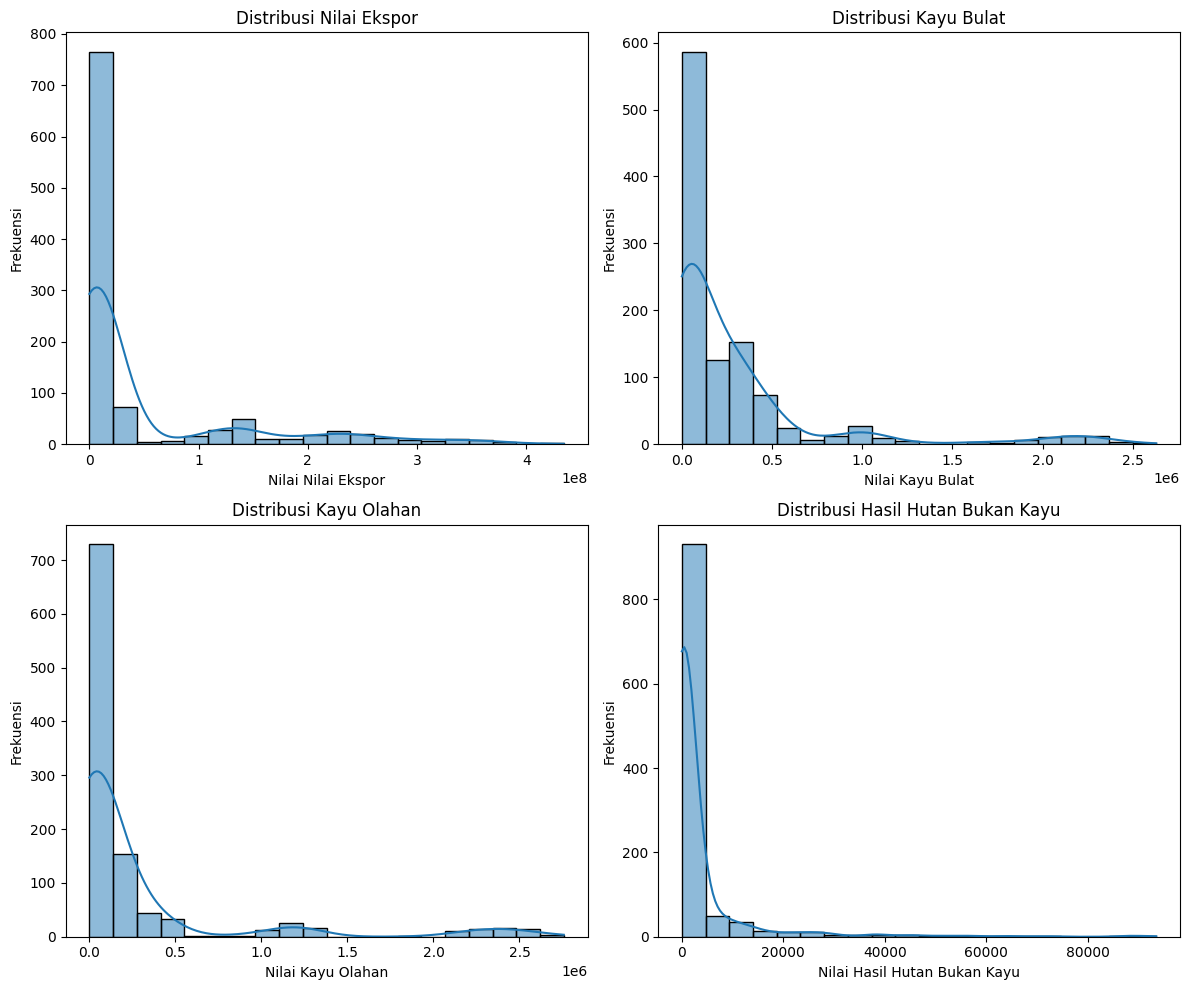

In [ ]:
# Variabel yang akan diplot
numeric_cols = ['Nilai Ekspor', 'Kayu Bulat', 'Kayu Olahan', 'Hasil Hutan Bukan Kayu']

# Menentukan ukuran figure
plt.figure(figsize=(12, 10))

# Loop untuk membuat histogram
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i + 1)  # 2 baris, 2 kolom
    sns.histplot(merged_data[col], kde=True, bins=20)  # Plot histogram dengan KDE dan bins tertentu
    plt.title(f'Distribusi {col}')  # Menambahkan judul
    plt.xlabel(f'Nilai {col}')  # Menambahkan label sumbu X yang lebih spesifik
    plt.ylabel('Frekuensi')  # Menambahkan label sumbu Y yang lebih spesifik

# Menyesuaikan layout agar tidak tumpang tindih
plt.tight_layout()
plt.show()

### EDA: Pengecekan Outlier

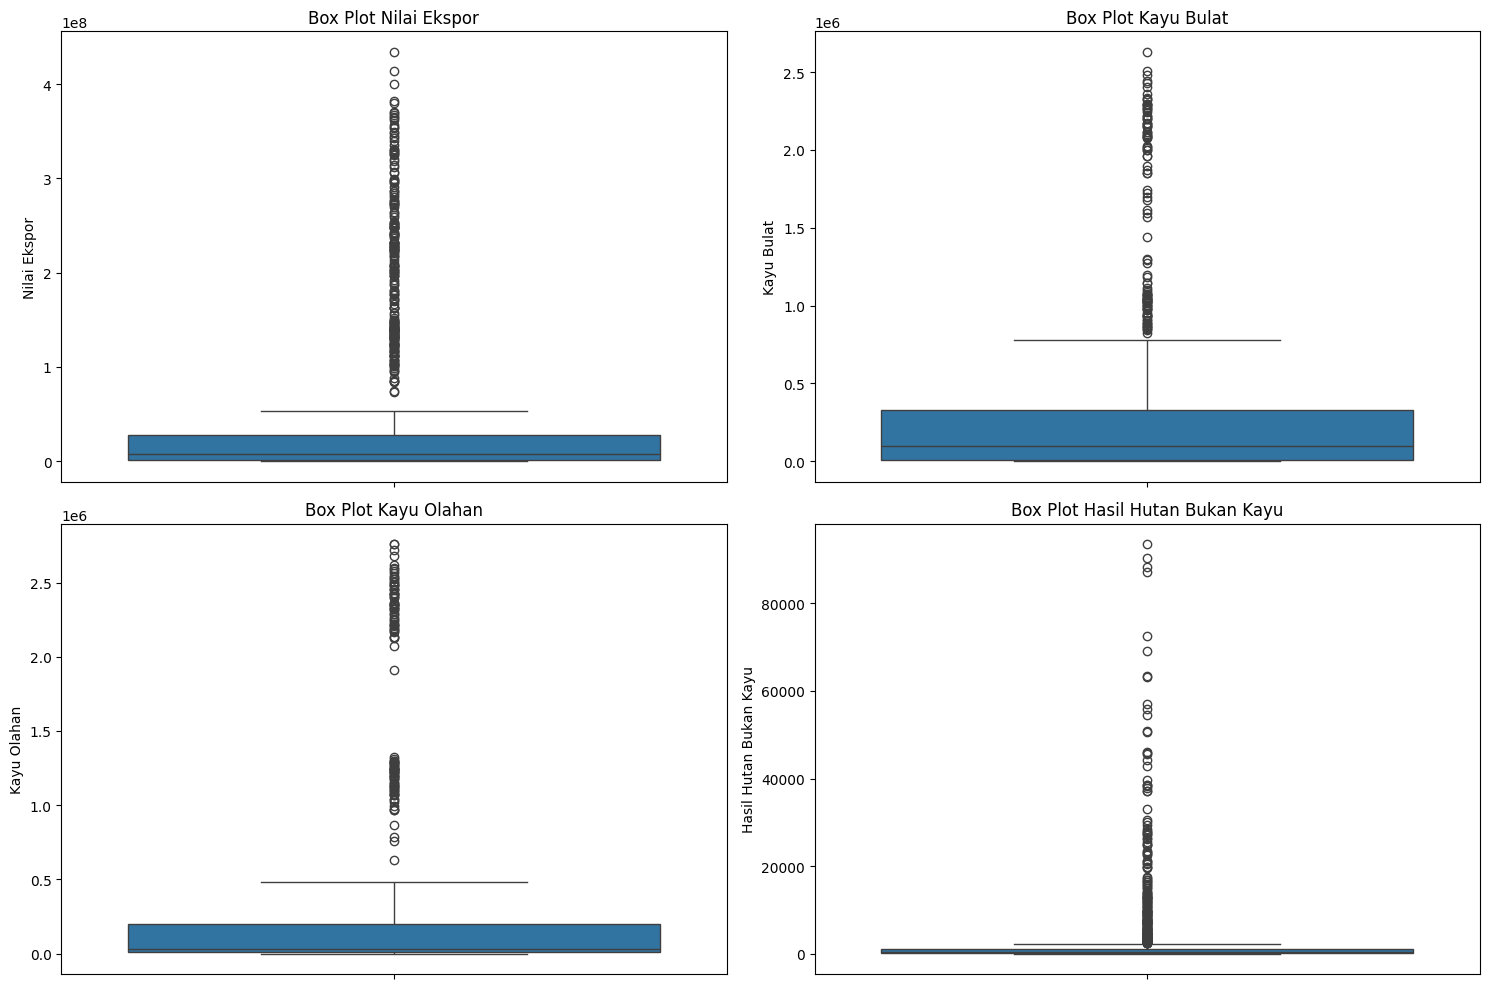

In [ ]:
numeric_cols = ['Nilai Ekspor', 'Kayu Bulat', 'Kayu Olahan', 'Hasil Hutan Bukan Kayu'] # Hanya kolom 'Nilai' yang relevan untuk outlier
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i + 1) # 2 baris, 2 kolom
    sns.boxplot(y=merged_data[col])
    plt.title(f'Box Plot {col}')
plt.tight_layout()
plt.show()

### EDA: Korelasi (Heatmap)

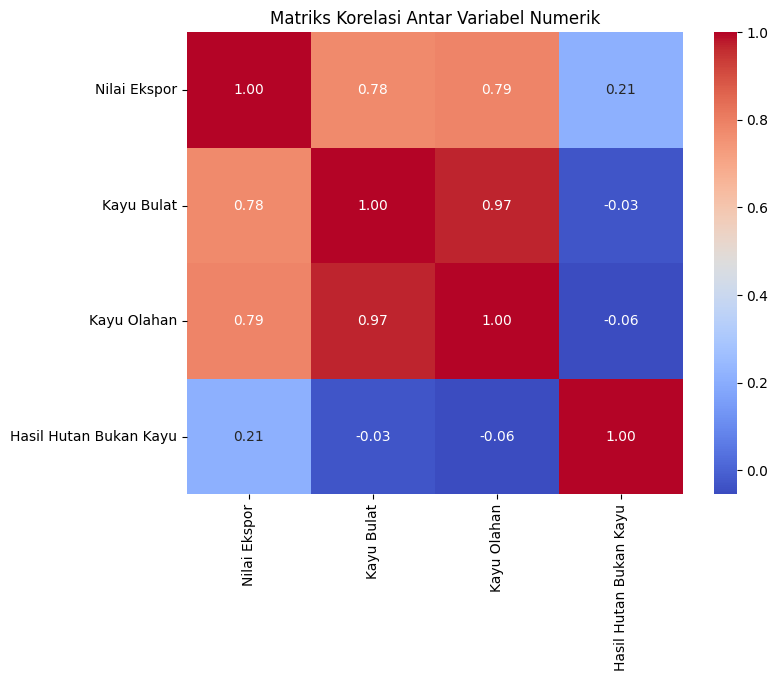

In [ ]:
numeric_cols = ['Nilai Ekspor', 'Kayu Bulat', 'Kayu Olahan', 'Hasil Hutan Bukan Kayu']
correlation_matrix = merged_data[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Antar Variabel Numerik')
plt.show()

### EDA: Grafik Hubungan Bivariat (antara 2 variabel)

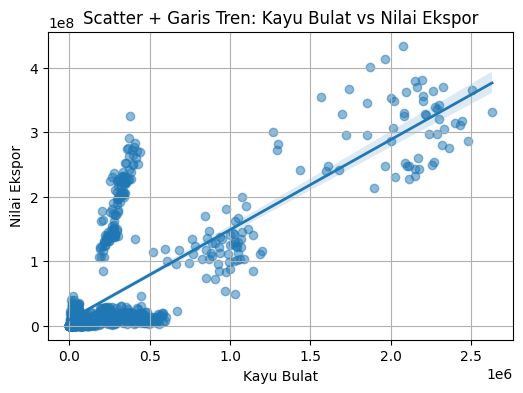

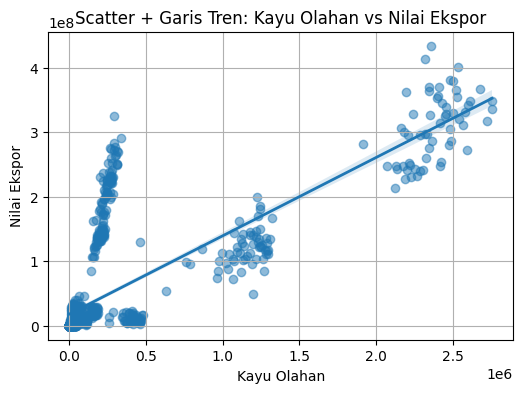

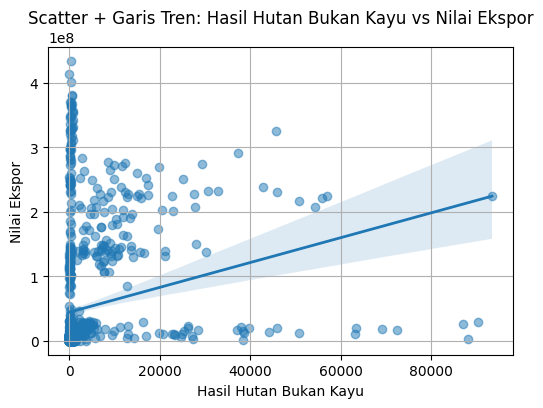

In [ ]:
x_vars = ['Kayu Bulat', 'Kayu Olahan', 'Hasil Hutan Bukan Kayu']
y_var = 'Nilai Ekspor'

for x in x_vars:
    plt.figure(figsize=(6,4))
    sns.regplot(data=merged_data, x=x, y=y_var, scatter_kws={'alpha':0.5}, line_kws={'linewidth':2})
    plt.title(f'Scatter + Garis Tren: {x} vs {y_var}')
    plt.grid(True)
    plt.show()


### Featuring Variabel

In [ ]:
# =========================
# DEFINISI FEATURE (BENAR)
# =========================

# Provinsi dan Bulan -> kategorikal
categorical_features = ["Provinsi", "Bulan"]

# Tahun + variabel produksi -> numerik
numeric_features = ["Kayu Bulat", "Kayu Olahan", "Hasil Hutan Bukan Kayu"]

# X = variabel independen
X = merged_data[categorical_features + numeric_features].copy()

# y = variabel dependen
y = merged_data["Nilai Ekspor"].copy()

# Cek data
display(X.head())
display(y.head())


,Provinsi,Bulan,Kayu Bulat,Kayu Olahan,Hasil Hutan Bukan Kayu
0,BALI,1,1876.63,1429.31,111.578333
1,BALI,2,2530.42,803.81,111.578333
2,BALI,3,2254.45,829.67,111.578333
3,BALI,4,1912.29,668.06,111.578333
4,BALI,5,749.41,458.88,111.578333


,Nilai Ekspor
0,198165.23
1,148026.86
2,219988.23
3,28269.71
4,80816.03


## Transformasi Data

In [ ]:
# Encoder kompatibel lintas versi sklearn
try:
    categorical_transformer = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    categorical_transformer = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

numeric_transformer = RobustScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numeric_transformer, numeric_features),
    ],
    remainder="drop"
)

pipeline_mlr = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearRegression()),
    ]
)


## Split Data

In [ ]:
# 1) Konversi aman: semua yang tidak bisa jadi angka akan jadi NaN
year_num = pd.to_numeric(merged_data["Tahun"], errors="coerce")

# 2) Buang baris yang Tahun nya NaN (biar mask tidak bikin error)
valid_mask = year_num.notna()

X2 = X.loc[valid_mask].copy()
y2 = y.loc[valid_mask].copy()
year2 = year_num.loc[valid_mask].astype("int64")

# 3) Split waktu: train 2020–2023, test 2024
train_mask = year2 < 2024
test_mask  = year2 == 2024

X_train = X2.loc[train_mask]
y_train = y2.loc[train_mask]
X_test  = X2.loc[test_mask]
y_test  = y2.loc[test_mask]

print("Jumlah data total :", len(merged_data))
print("Jumlah data valid :", len(X2))
print("Jumlah train      :", len(X_train))
print("Jumlah test       :", len(X_test))


Jumlah data total : 1080
Jumlah data valid : 1080
Jumlah train      : 864
Jumlah test       : 216


## Fit Model

In [ ]:
# =========================================================
# 1) FIT MODEL
# =========================================================
pipeline_mlr.fit(X_train, y_train)

# =========================================================
# 2) PREDIKSI
# =========================================================
y_pred_train  = pipeline_mlr.predict(X_train)
y_pred_test   = pipeline_mlr.predict(X_test)
y_pred_global = pipeline_mlr.predict(X)

merged_data["Prediksi"] = y_pred_global
merged_data["Residual"] = merged_data["Nilai Ekspor"] - merged_data["Prediksi"]

# =========================================================
# 3) FUNGSI METRIK
# =========================================================
def eval_regression(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Akurasi_R2(%)": r2 * 100
    }

# =========================================================
# 4) TABEL EVALUASI (SAJA)
# =========================================================
eval_df = pd.DataFrame([
    {"Dataset": "Train (2020–2023)",  **eval_regression(y_train,  y_pred_train)},
    {"Dataset": "Test (2024)",        **eval_regression(y_test,   y_pred_test)},
    {"Dataset": "Global (2020–2024)", **eval_regression(y,        y_pred_global)},
])

display(eval_df)


,Dataset,R2,MSE,RMSE,MAE,Akurasi_R2(%)
0,Train (2020–2023),0.966750,2.594111e+14,1.610625e+07,8.333074e+06,96.675000
1,Test (2024),0.978016,1.917018e+14,1.384564e+07,8.263923e+06,97.801569
2,Global (2020–2024),0.969212,2.458693e+14,1.568022e+07,8.319244e+06,96.921162


## Konstanta dan Koefisien

In [ ]:
# Ambil data yang dipakai untuk regresi (hapus baris yang ada NaN di kolom penting)
df = merged_data[['Nilai Ekspor', 'Kayu Bulat', 'Kayu Olahan', 'Hasil Hutan Bukan Kayu']].dropna().copy()

# X (variabel bebas) dan y (variabel terikat)
X = df[['Kayu Bulat', 'Kayu Olahan', 'Hasil Hutan Bukan Kayu']]
y = df['Nilai Ekspor']

# Fit model
lr = LinearRegression()
lr.fit(X, y)

# Ambil konstanta dan koefisien
intercept = lr.intercept_
coefs = lr.coef_

# Tampilkan rapi
hasil = pd.DataFrame({
    'Variabel': ['Konstanta', 'Kayu Bulat', 'Kayu Olahan', 'Hasil Hutan Bukan Kayu'],
    'Koefisien': [intercept, coefs[0], coefs[1], coefs[2]]
})

display(hasil)

,Variabel,Koefisien
0,Konstanta,7.775887e+06
1,Kayu Bulat,2.935818e+01
2,Kayu Olahan,9.912626e+01
3,Hasil Hutan Bukan Kayu,2.302140e+03


## Tabel Prediksi Bulanan

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# TABEL BULANAN (DATA UJI 2024) - AGREGAT NASIONAL
# =========================================================

# 1) Ambil subset test set (2024) + pastikan numerik
df_test_2024 = merged_data.loc[
    merged_data["Tahun"].astype(int) == 2024,
    ["Tahun", "Bulan", "Nilai Ekspor", "Prediksi"]
].copy()

df_test_2024["Bulan"] = pd.to_numeric(df_test_2024["Bulan"], errors="coerce").astype("Int64")
df_test_2024["Nilai Ekspor"] = pd.to_numeric(df_test_2024["Nilai Ekspor"], errors="coerce")
df_test_2024["Prediksi"] = pd.to_numeric(df_test_2024["Prediksi"], errors="coerce")
df_test_2024 = df_test_2024.dropna(subset=["Bulan", "Nilai Ekspor", "Prediksi"])

# 2) Fungsi metrik per bulan (berdasarkan seluruh provinsi di bulan tsb)
def monthly_metrics(g):
    y_true = g["Nilai Ekspor"].to_numpy()
    y_pred = g["Prediksi"].to_numpy()

    # Guard R2: butuh minimal 2 sampel dan y_true tidak konstan
    if (len(y_true) < 2) or (np.allclose(y_true, y_true[0])):
        r2 = np.nan
    else:
        r2 = r2_score(y_true, y_pred)

    return pd.Series({
        "Aktual (Sum)": y_true.sum(),
        "Prediksi (Sum)": y_pred.sum(),
        "Selisih (Sum)": (y_true - y_pred).sum(),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2,
        "N_Observasi": len(g)
    })

# 3) Tabel bulanan 2024
tabel_bulanan_2024 = (
    df_test_2024
    .groupby("Bulan", as_index=False)
    .apply(monthly_metrics)
    .reset_index(drop=True)
    .sort_values("Bulan")
)

# 4) (Opsional) tambah nama bulan biar enak dibaca
nama_bulan = {
    1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"Mei",6:"Jun",
    7:"Jul",8:"Agu",9:"Sep",10:"Okt",11:"Nov",12:"Des"
}
tabel_bulanan_2024.insert(1, "Nama Bulan", tabel_bulanan_2024["Bulan"].map(nama_bulan))

# 5) Tampilkan
display(tabel_bulanan_2024)



/tmp/ipython-input-218/2213568088.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(monthly_metrics)


,Bulan,Nama Bulan,Aktual (Sum),Prediksi (Sum),Selisih (Sum),MAE,RMSE,R2,N_Observasi
0,1,Jan,7.620397e+08,8.939343e+08,-1.318947e+08,9.137172e+06,1.519704e+07,0.962542,18.0
1,2,Feb,8.247840e+08,9.079407e+08,-8.315668e+07,7.545617e+06,1.111338e+07,0.984437,18.0
2,3,Mar,9.071196e+08,9.964557e+08,-8.933611e+07,6.612243e+06,8.572036e+06,0.991147,18.0
3,4,Apr,8.151822e+08,8.949634e+08,-7.978116e+07,1.067999e+07,1.788478e+07,0.960538,18.0
4,5,Mei,8.298458e+08,9.653594e+08,-1.355136e+08,9.353908e+06,1.481370e+07,0.972800,18.0
5,6,Jun,8.624016e+08,9.117849e+08,-4.938321e+07,6.991703e+06,1.168482e+07,0.983260,18.0
6,7,Jul,8.966856e+08,9.460369e+08,-4.935127e+07,5.399480e+06,7.827575e+06,0.992492,18.0
7,8,Agu,1.007060e+09,9.179365e+08,8.912397e+07,9.081749e+06,1.779140e+07,0.971059,18.0
8,9,Sep,9.477980e+08,9.589394e+08,-1.114136e+07,9.196427e+06,1.453529e+07,0.977986,18.0
9,10,Okt,9.725510e+08,9.103666e+08,6.218440e+07,9.628918e+06,1.732116e+07,0.970834,18.0


## Grafik Aktual dan Prediksi

/tmp/ipython-input-218/4270865255.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


nm OK. shape = (60, 4)
     Tanggal        Aktual      Prediksi       Selisih
0 2020-01-01  7.928302e+08  8.577128e+08 -6.488254e+07
1 2020-02-01  7.748845e+08  8.570587e+08 -8.217424e+07
2 2020-03-01  7.819968e+08  8.732604e+08 -9.126361e+07
3 2020-04-01  7.814607e+08  9.022281e+08 -1.207674e+08
4 2020-05-01  7.043849e+08  9.057093e+08 -2.013244e+08


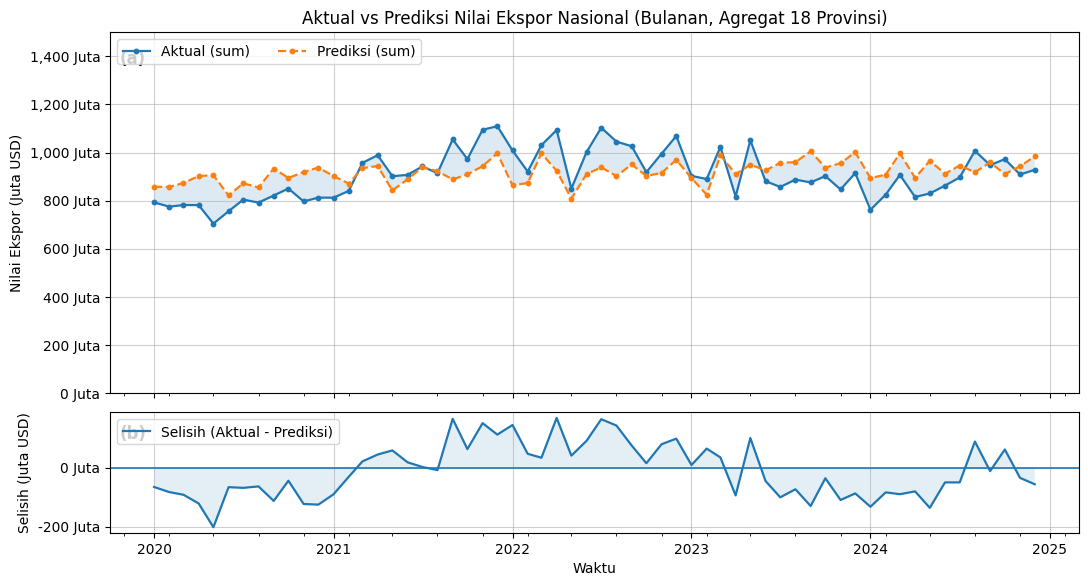

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# ===============================
# 1) BIKIN nm DARI merged_data
# ===============================
req_cols = ["Tahun", "Bulan", "Nilai Ekspor", "Prediksi"]
missing = [c for c in req_cols if c not in merged_data.columns]
if missing:
    raise KeyError(
        f"Kolom ini tidak ada di merged_data: {missing}.\n"
        f"Kolom yang tersedia: {list(merged_data.columns)}"
    )

tmp = merged_data[req_cols].copy()

tmp["Tahun"] = pd.to_numeric(tmp["Tahun"], errors="coerce")
tmp["Bulan"] = pd.to_numeric(tmp["Bulan"], errors="coerce")
tmp["Nilai Ekspor"] = pd.to_numeric(tmp["Nilai Ekspor"], errors="coerce")
tmp["Prediksi"] = pd.to_numeric(tmp["Prediksi"], errors="coerce")
tmp = tmp.dropna(subset=req_cols)

if tmp.empty:
    raise ValueError("Data kosong setelah konversi numerik + dropna. Cek isi merged_data dan kolomnya.")

tmp["Tanggal"] = pd.to_datetime(
    tmp["Tahun"].astype(int).astype(str) + "-" +
    tmp["Bulan"].astype(int).astype(str).str.zfill(2) + "-01",
    errors="coerce"
)
tmp = tmp.dropna(subset=["Tanggal"])

nm = (
    tmp.groupby("Tanggal", as_index=False)
       .agg(
            Aktual=("Nilai Ekspor", "sum"),
            Prediksi=("Prediksi", "sum")
        )
       .sort_values("Tanggal")
)

nm["Selisih"] = nm["Aktual"] - nm["Prediksi"]

if nm.empty or len(nm) < 2:
    raise ValueError(f"nm kosong / terlalu sedikit titik untuk diplot. Jumlah baris nm = {len(nm)}")

print("nm OK. shape =", nm.shape)
print(nm.head())

# ===============================
# 2) PLOT (dengan label (a) & (b))
# ===============================

# Formatter Y: JUTA
fmt_y = FuncFormatter(lambda x, _: f"{x/1_000_000:,.0f} Juta")

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12.5, 6.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08}
)

# --- Panel (a): Aktual vs Prediksi ---
ax1.plot(nm["Tanggal"], nm["Aktual"], marker="o", ms=3.2, lw=1.6, label="Aktual (sum)")
ax1.plot(nm["Tanggal"], nm["Prediksi"], marker="o", ms=3.2, lw=1.6, ls="--", label="Prediksi (sum)")
ax1.fill_between(nm["Tanggal"], nm["Aktual"], nm["Prediksi"], alpha=0.15)

ax1.set(
    title="Aktual vs Prediksi Nilai Ekspor Nasional (Bulanan, Agregat 18 Provinsi)",
    ylabel="Nilai Ekspor (Juta USD)"
)

# Range Y 0–1500 Juta
ax1.set_ylim(0, 1_500_000_000)
ax1.yaxis.set_major_formatter(fmt_y)
ax1.grid(True, alpha=0.6)
ax1.legend(loc="upper left", ncol=2, frameon=True)

# Label panel (a)
ax1.text(
    0.01, 0.95, "(a)",
    transform=ax1.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left"
)

# --- Panel (b): Selisih ---
ax2.plot(nm["Tanggal"], nm["Selisih"], lw=1.6, label="Selisih (Aktual - Prediksi)")
ax2.axhline(0, lw=1.2)
ax2.fill_between(nm["Tanggal"], nm["Selisih"], 0, alpha=0.12)

ax2.set(
    ylabel="Selisih (Juta USD)",
    xlabel="Waktu"
)

ax2.yaxis.set_major_formatter(fmt_y)
ax2.grid(True, alpha=0.6)
ax2.legend(loc="upper left", frameon=True)

# Label panel (b)
ax2.text(
    0.01, 0.90, "(b)",
    transform=ax2.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left"
)

# X-axis formatting
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

plt.tight_layout()
plt.show()
